In [13]:
### Import necessary libraries for modeling ###
import os
import pandas as pd
import numpy as np
import torch
import random
import json
import matplotlib.pyplot as plt
from itables import show

from scipy.stats import kendalltau
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

In [2]:
# Set random seed for reproducibility
TARGET_VARIABLE = "Mole fraction"
torch.manual_seed(101)
np.random.seed(101)
random.seed(101)

In [4]:
X_train = pd.read_csv("./processed_data/X_train.csv")
X_test = pd.read_csv("./processed_data/X_test.csv")
X_val = pd.read_csv("./processed_data/X_val.csv")
y_train = pd.read_csv("./processed_data/y_train.csv")
y_test = pd.read_csv("./processed_data/y_test.csv")
y_val = pd.read_csv("./processed_data/y_val.csv")

In [5]:
X_train.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)
X_test.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)
X_val.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)

In [16]:
def evaluate_model(
    model,
    X_test: pd.DataFrame,
    y_test,
    show_plot: bool = False,
    save_file: bool = False,
    save_path: str = "./Linear/Linear_test_results.json",
    plot_save_dir: str = "./linear_baseline",
) -> None | str:
    """Evaluate the model's performance on the test set and optionally save the results."""
    # check if model is provided
    assert model is not None, "Model must be provided for evaluation."

    y_pred = model.predict(X_test)
    y_test = np.array(y_test).flatten()
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    tau = kendalltau(y_test, y_pred).correlation

    # Bootstrap — only for CI
    rng = np.random.default_rng(101)
    mae_scores = []
    mse_scores = []
    r2_scores = []
    tau_scores = []
    for _ in range(1000):
        idx = rng.integers(0, len(y_test), len(y_test))
        mae_scores.append(mean_absolute_error(y_test[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_test[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_test[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_test[idx], y_pred[idx]).correlation)

    mae_scores = np.array(mae_scores)
    mse_scores = np.array(mse_scores)
    r2_scores = np.array(r2_scores)
    tau_scores = np.array(tau_scores)

    mae_std = np.std(mae_scores)
    mse_std = np.std(mse_scores)
    r2_std = np.std(r2_scores)
    tau_std = np.std(tau_scores)

    mae_ci = np.percentile(mae_scores, [2.5, 97.5])
    mse_ci = np.percentile(mse_scores, [2.5, 97.5])
    r2_ci = np.percentile(r2_scores, [2.5, 97.5])
    tau_ci = np.percentile(tau_scores, [2.5, 97.5])

    print(
        f"MAE          = {mae:.4f}, Std: {mae_std:.4f} (95% CI: {mae_ci[0]:.4f}–{mae_ci[1]:.4f})"
    )
    print(
        f"MSE          = {mse:.4f}, Std: {mse_std:.4f} (95% CI: {mse_ci[0]:.4f}–{mse_ci[1]:.4f})"
    )
    print(
        f"R²           = {r2:.4f}, Std: {r2_std:.4f} (95% CI: {r2_ci[0]:.4f}–{r2_ci[1]:.4f})"
    )
    print(
        f"Kendall's τ  = {tau:.4f}, Std: {tau_std:.4f} (95% CI: {tau_ci[0]:.4f}–{tau_ci[1]:.4f})"
    )

    if save_file:
        results = {
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R^2 Score": r2,
            "Kendall's Tau": tau,
        }
        with open(save_path, "w") as f:
            json.dump(results, f)
        print(f"Test results saved to {save_path}")

    if show_plot:
        os.makedirs(plot_save_dir, exist_ok=True)

        # Actual vs Predicted scatter plot
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(y_test, y_pred, alpha=0.1, s=10)
        ax.plot([0, 1], [0, 1], "r--", label="Perfect fit")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title("Actual vs Predicted")
        ax.legend()
        scatter_path = os.path.join(plot_save_dir, "actual_vs_predicted.png")
        fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Scatter plot saved to {scatter_path}")

        # Distribution histogram: true vs predicted
        fig, ax = plt.subplots(figsize=(7, 5))
        bins = np.linspace(0, 1, 50)
        ax.hist(
            y_test,
            bins=bins,
            alpha=0.6,
            label="True",
            color="steelblue",
            edgecolor="none",
        )
        ax.hist(
            y_pred,
            bins=bins,
            alpha=0.6,
            label="Predicted",
            color="darkorange",
            edgecolor="none",
        )
        ax.set_xlim(0, 1)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.set_title("Distribution: True vs Predicted")
        ax.legend()
        hist_path = os.path.join(plot_save_dir, "distribution_histogram.png")
        fig.savefig(hist_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Histogram saved to {hist_path}")

    return None

MAE          = 1.9232, Std: 1.0134 (95% CI: 0.3152–4.2856)
MSE          = 10733.2983, Std: 7848.6073 (95% CI: 23.1330–29448.8867)
R²           = -112782.8081, Std: 82520.0178 (95% CI: -307662.9278–-242.1613)
Kendall's τ  = 0.2335, Std: 0.0063 (95% CI: 0.2206–0.2453)


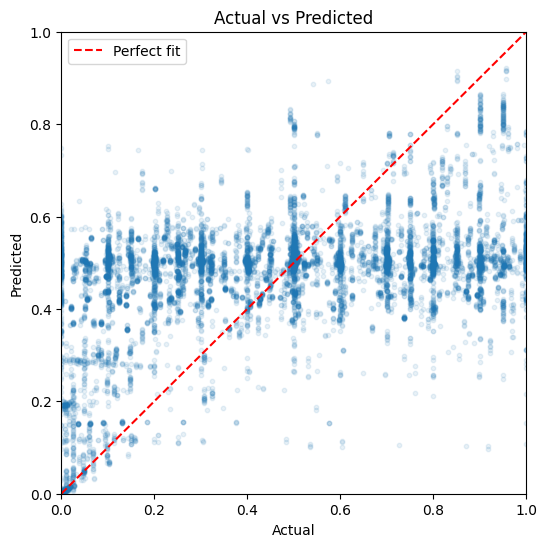

Scatter plot saved to ./linear_baseline\actual_vs_predicted.png


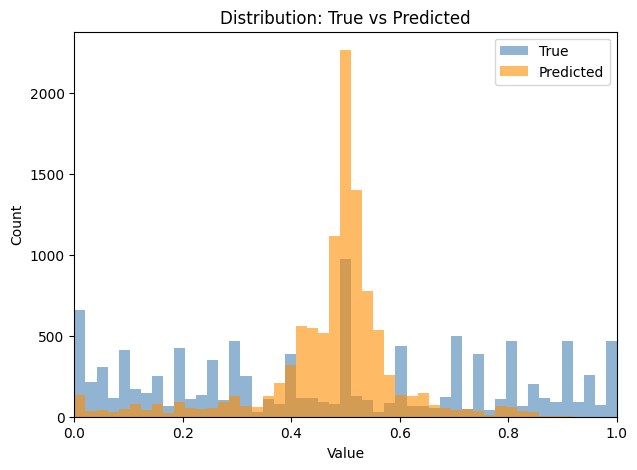

Histogram saved to ./linear_baseline\distribution_histogram.png


In [17]:
# Scale features (good practice even for linear regression)
pipeline = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

pipeline.fit(X_train, y_train)
evaluate_model(pipeline, X_test, y_test, show_plot=True)

In [8]:
joblib.dump(pipeline, "linear_baseline.pkl")

['linear_baseline.pkl']

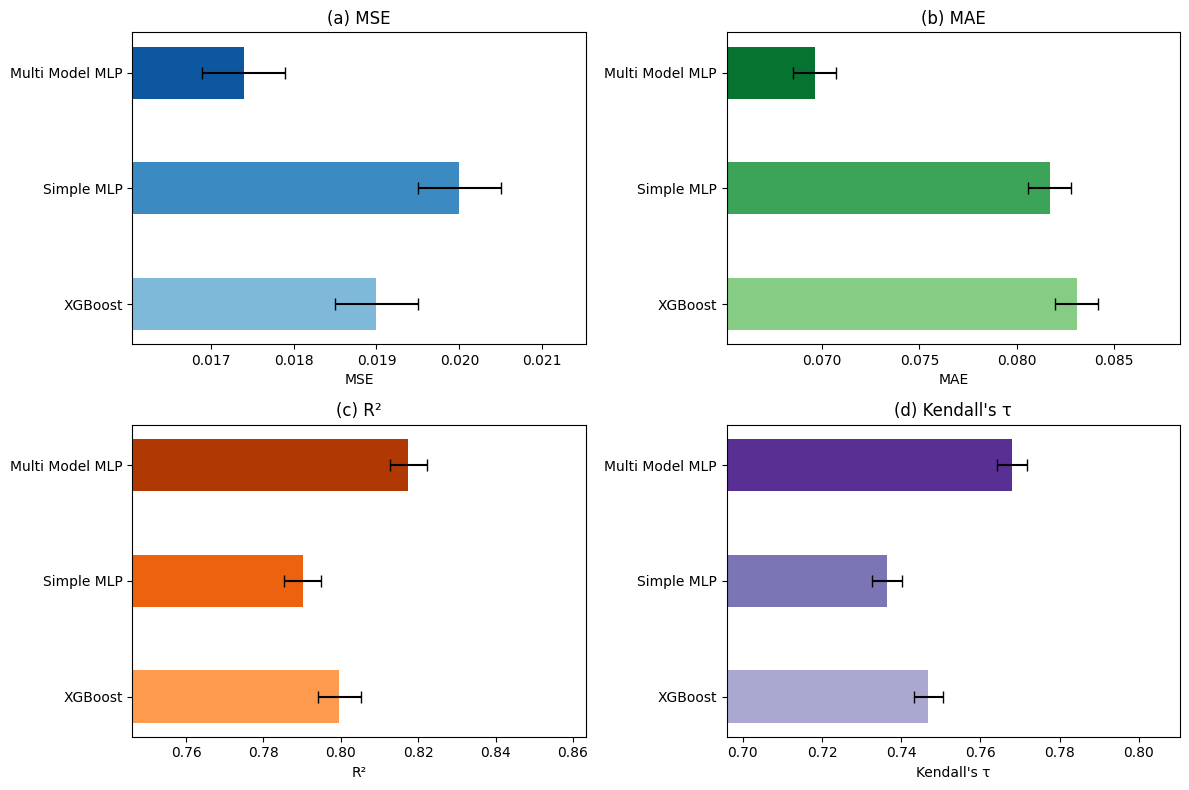

In [24]:
models = ["XGBoost", "Simple MLP", "Multi Model MLP"]

metrics = {
    "MSE": [0.0190, 0.0200, 0.0174],
    "MAE": [0.0831, 0.0817, 0.0696],
    "R²": [0.7996, 0.7902, 0.8175],
    "Kendall's τ": [0.7468, 0.7363, 0.7680],
}

errors = {
    "MSE": [0.0005, 0.0005, 0.0005],
    "MAE": [0.0011, 0.0011, 0.0011],
    "R²": [0.0055, 0.0048, 0.0047],
    "Kendall's τ": [0.0037, 0.0038, 0.0038],
}

labels = ["(a)", "(b)", "(c)", "(d)"]
cmaps = [plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = np.array(metrics[metric])
    errs = np.array(errors[metric])
    y = np.arange(len(models))

    # different color scale for each subplot
    colors = cmaps[i](np.linspace(0.45, 0.85, len(models)))

    axes[i].barh(y, values, xerr=errs, height=0.45, color=colors, capsize=4)

    axes[i].set_yticks(y)
    axes[i].set_yticklabels(models)
    axes[i].set_xlabel(metric)
    axes[i].set_title(f"{labels[i]} {metric}")

    xmin = max(0, np.min(values - errs) * 0.95)
    xmax = np.max(values + errs) * 1.05
    axes[i].set_xlim(xmin, xmax)

plt.tight_layout()
plt.savefig(
    "model_metrics_subplots_horizontal_colormaps.png", dpi=300, bbox_inches="tight"
)
plt.show()